# RQ2: The Grid — Does Qualifying Predict the Race?

**Research Question:** *How strongly does grid (qualifying) position predict race finishing position, and does this differ between street circuits and permanent circuits?*

This notebook explores the relationship between starting position and finishing position across 25,000+ race entries. The scatter plot prototype here was later reproduced as an interactive D3.js visualization with regression overlays, circuit-type filtering, and a Monaco 2024 spotlight.

**Dataset:** `rq2_grid_finish_circuits.csv` — individual race entries with grid position, finish position, circuit type, and race metadata.

In [15]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

pd.set_option('display.max_rows', 100)

df = pd.read_csv('../final_datasets/rq2_grid_finish_circuits.csv')
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (25238, 10)

Column types:
Year                 int64
Race Name           object
Circuit Name        object
Driver              object
Constructor         object
Grid Position      float64
Finish Position    float64
Points             float64
Dataset             object
Circuit Type        object
dtype: object

First 5 rows:


,Year,Race Name,Circuit Name,Driver,Constructor,Grid Position,Finish Position,Points,Dataset,Circuit Type
0,2008,Australian GP,Albert Park Grand Prix Circuit,Lewis Hamilton,McLaren,1.0,1.0,10.0,Historical (1950-2017),Street Circuit
1,2008,Australian GP,Albert Park Grand Prix Circuit,Nick Heidfeld,Sauber,5.0,2.0,8.0,Historical (1950-2017),Street Circuit
2,2008,Australian GP,Albert Park Grand Prix Circuit,Nico Rosberg,Williams,7.0,3.0,6.0,Historical (1950-2017),Street Circuit
3,2008,Australian GP,Albert Park Grand Prix Circuit,Fernando Alonso,Renault,11.0,4.0,5.0,Historical (1950-2017),Street Circuit
4,2008,Australian GP,Albert Park Grand Prix Circuit,Heikki Kovalainen,McLaren,3.0,5.0,4.0,Historical (1950-2017),Street Circuit


## 1. Data Quality Check

In [16]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nYear range: {df['Year'].min()} – {df['Year'].max()}")
print(f"Unique drivers: {df['Driver'].nunique()}")
print(f"Unique tracks (Race Name): {df['Race Name'].nunique()}")
print(f"\nCircuit Type distribution:")
print(df['Circuit Type'].value_counts())

Missing values per column:
Year               0
Race Name          0
Circuit Name       0
Driver             0
Constructor        0
Grid Position      0
Finish Position    0
Points             0
Dataset            0
Circuit Type       0
dtype: int64

Duplicate rows: 0

Year range: 1950 – 2026
Unique drivers: 799
Unique tracks (Race Name): 46

Circuit Type distribution:
Circuit Type
Permanent Circuit    22289
Street Circuit        2949
Name: count, dtype: int64


## 2. Descriptive Statistics

In [17]:
print("Descriptive statistics:\n")
df[['Grid Position', 'Finish Position', 'Points']].describe().round(2)

Descriptive statistics:



,Grid Position,Finish Position,Points
count,25238.00,25238.00,25238.00
mean,11.86,11.72,2.21
std,6.85,6.80,4.57
min,1.00,1.00,0.00
25%,6.00,6.00,0.00
50%,12.00,11.00,0.00
75%,17.00,17.00,2.00
max,71.00,34.00,50.00


## 3. Position Change Analysis

Creating a derived column: `Position Change = Finish Position - Grid Position`. Negative means gained positions, positive means lost positions.

In [18]:
# Filter valid entries (same as D3 does)
valid = df[(df['Grid Position'] > 0) & (df['Finish Position'] > 0) &
           (df['Grid Position'] <= 26) & (df['Finish Position'] <= 26)].copy()

valid['Position Change'] = valid['Finish Position'] - valid['Grid Position']

print(f"Valid entries: {len(valid)} out of {len(df)}")
print(f"\nCorrelation (Grid vs Finish):")
print(f"  Overall:   r = {valid['Grid Position'].corr(valid['Finish Position']):.4f}")
print(f"  Street:    r = {valid[valid['Circuit Type'] == 'Street Circuit']['Grid Position'].corr(valid[valid['Circuit Type'] == 'Street Circuit']['Finish Position']):.4f}")
print(f"  Permanent: r = {valid[valid['Circuit Type'] == 'Permanent Circuit']['Grid Position'].corr(valid[valid['Circuit Type'] == 'Permanent Circuit']['Finish Position']):.4f}")

print(f"\nPosition change stats:")
valid['Position Change'].describe().round(2)

Valid entries: 24956 out of 25238

Correlation (Grid vs Finish):
  Overall:   r = 0.4524
  Street:    r = 0.4371
  Permanent: r = 0.4542

Position change stats:


count    24956.00
mean        -0.13
std          7.00
min        -23.00
25%         -4.00
50%         -1.00
75%          3.00
max         25.00
Name: Position Change, dtype: float64

---
## Visualization Prototyping

## 4. Grid and Finish Position Distributions

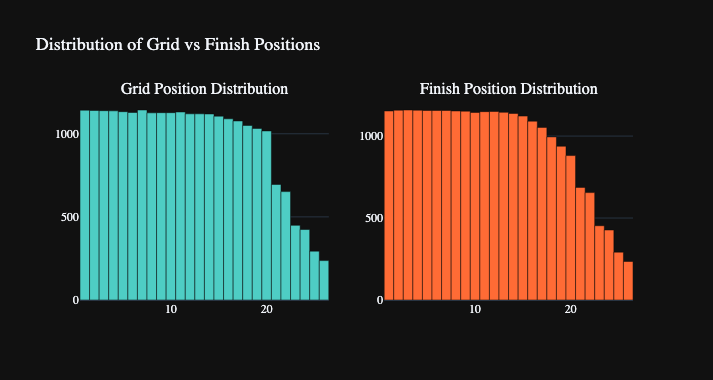

In [19]:
fig = make_subplots(rows=1, cols=2, subplot_titles=('Grid Position Distribution', 'Finish Position Distribution'))

fig.add_trace(go.Histogram(
    x=valid['Grid Position'], nbinsx=26,
    marker_color='#4ecdc4', marker_line_color='#0a0a0a', marker_line_width=0.5,
    name='Grid'
), row=1, col=1)

fig.add_trace(go.Histogram(
    x=valid['Finish Position'], nbinsx=26,
    marker_color='#ff6b35', marker_line_color='#0a0a0a', marker_line_width=0.5,
    name='Finish'
), row=1, col=2)

fig.update_layout(
    title='Distribution of Grid vs Finish Positions',
    template='plotly_dark', height=380,
    font=dict(family='DM Sans'), title_font_size=18,
    showlegend=False
)
fig.show()

## 5. Position Change Distribution

How many positions do drivers typically gain or lose during a race? Negative = gained positions, positive = dropped.

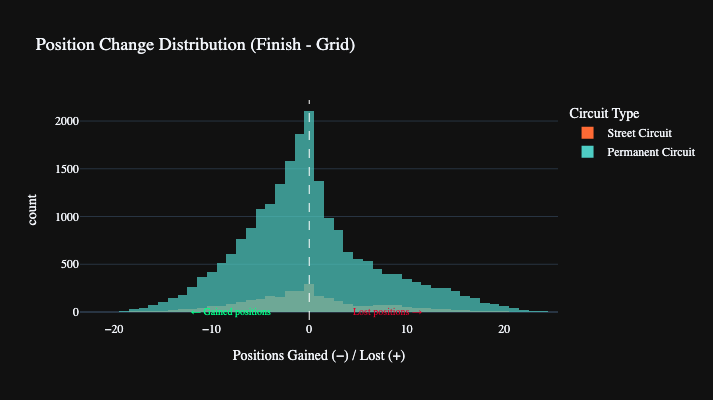

In [20]:
fig = px.histogram(
    valid, x='Position Change', nbins=50,
    color='Circuit Type',
    color_discrete_map={'Street Circuit': '#ff6b35', 'Permanent Circuit': '#4ecdc4'},
    barmode='overlay',
    title='Position Change Distribution (Finish - Grid)',
    labels={'Position Change': 'Positions Gained (−) / Lost (+)'},
    template='plotly_dark', opacity=0.7
)
fig.add_vline(x=0, line_dash='dash', line_color='white', line_width=1)
fig.update_layout(
    font=dict(family='DM Sans'), title_font_size=18, height=400,
    annotations=[dict(
        x=-8, y=0, xref='x', yref='y',
        text='← Gained positions', showarrow=False,
        font=dict(size=10, color='#00ff87')
    ), dict(
        x=8, y=0, xref='x', yref='y',
        text='Lost positions →', showarrow=False,
        font=dict(size=10, color='#e8002d')
    )]
)
fig.show()

## 6. Basic Scatter — Grid vs Finish (All Data)

The raw prototype — every race entry plotted. The diagonal dashed line represents "grid = finish" (no position change). Points above the line lost positions; below gained.

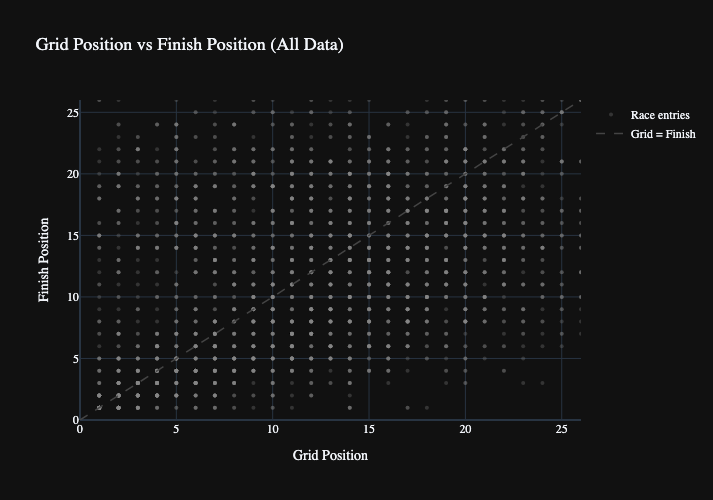

In [21]:
# Sample for performance (same approach as D3)
sample = valid.sample(n=min(3000, len(valid)), random_state=42)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=sample['Grid Position'], y=sample['Finish Position'],
    mode='markers',
    marker=dict(size=4, color='#888888', opacity=0.3),
    name='Race entries'
))

# Diagonal reference
fig.add_trace(go.Scatter(
    x=[0, 26], y=[0, 26],
    mode='lines',
    line=dict(dash='dash', color='#444444', width=1.5),
    name='Grid = Finish',
    showlegend=True
))

fig.update_layout(
    title='Grid Position vs Finish Position (All Data)',
    xaxis_title='Grid Position', yaxis_title='Finish Position',
    xaxis=dict(range=[0, 26]), yaxis=dict(range=[0, 26]),
    template='plotly_dark', height=500, width=550,
    font=dict(family='DM Sans'), title_font_size=18,
)
fig.show()

## 7. Scatter Colored by Circuit Type (D3 Prototype)

Splitting by circuit type reveals the core insight: street circuits (orange) cluster tighter around the diagonal than permanent circuits (teal). This is the primary visualization reproduced in D3.

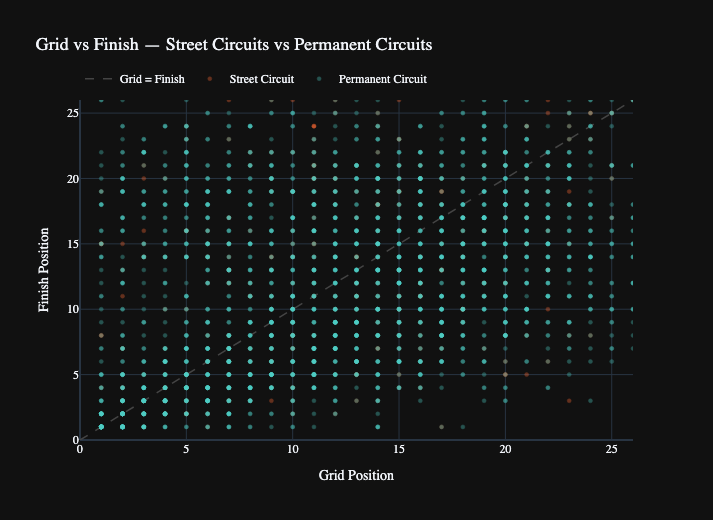

In [22]:
STREET_COLOR = '#ff6b35'
PERMANENT_COLOR = '#4ecdc4'

fig = go.Figure()

# Diagonal reference
fig.add_trace(go.Scatter(
    x=[0, 26], y=[0, 26], mode='lines',
    line=dict(dash='dash', color='#444444', width=1.5),
    name='Grid = Finish'
))

for ct, color in [('Street Circuit', STREET_COLOR), ('Permanent Circuit', PERMANENT_COLOR)]:
    subset = sample[sample['Circuit Type'] == ct]
    fig.add_trace(go.Scatter(
        x=subset['Grid Position'], y=subset['Finish Position'],
        mode='markers', name=ct,
        marker=dict(size=4, color=color, opacity=0.35,
                    line=dict(color=color, width=0.5)),
    ))

fig.update_layout(
    title='Grid vs Finish — Street Circuits vs Permanent Circuits',
    xaxis_title='Grid Position', yaxis_title='Finish Position',
    xaxis=dict(range=[0, 26]), yaxis=dict(range=[0, 26]),
    template='plotly_dark', height=520, width=580,
    font=dict(family='DM Sans'), title_font_size=18,
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show()

## 8. Scatter with Regression Lines and R-values

Adding linear regression per circuit type — matching the D3 visualization exactly. The regression slope and Pearson r show how predictive qualifying is for each circuit type.

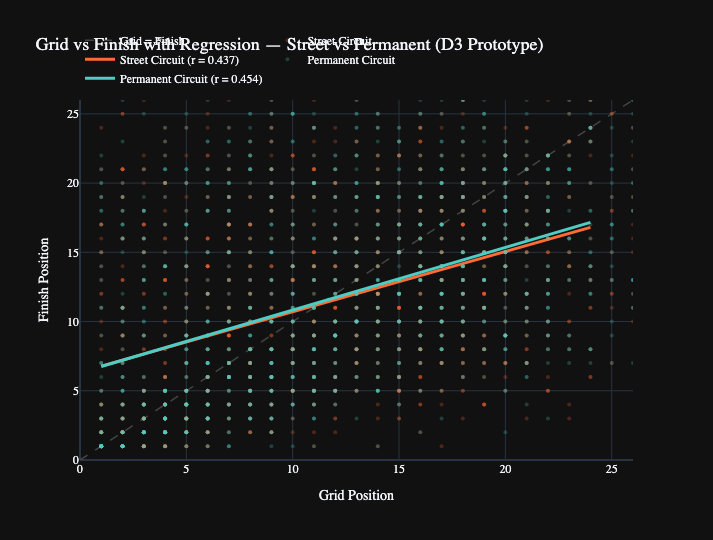

In [23]:
fig = go.Figure()

# Diagonal
fig.add_trace(go.Scatter(
    x=[0, 26], y=[0, 26], mode='lines',
    line=dict(dash='dash', color='#444444', width=1.5),
    name='Grid = Finish', showlegend=True
))

for ct, color in [('Street Circuit', STREET_COLOR), ('Permanent Circuit', PERMANENT_COLOR)]:
    subset = valid[valid['Circuit Type'] == ct]
    sample_ct = subset.sample(n=min(1500, len(subset)), random_state=42)
    
    # Scatter
    fig.add_trace(go.Scatter(
        x=sample_ct['Grid Position'], y=sample_ct['Finish Position'],
        mode='markers', name=ct,
        marker=dict(size=4, color=color, opacity=0.25),
    ))
    
    # Regression line
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        subset['Grid Position'], subset['Finish Position']
    )
    x_reg = np.array([1, 24])
    y_reg = slope * x_reg + intercept
    
    fig.add_trace(go.Scatter(
        x=x_reg, y=y_reg, mode='lines',
        line=dict(color=color, width=3),
        name=f'{ct} (r = {r_value:.3f})',
    ))

fig.update_layout(
    title='Grid vs Finish with Regression — Street vs Permanent (D3 Prototype)',
    xaxis_title='Grid Position', yaxis_title='Finish Position',
    xaxis=dict(range=[0, 26]), yaxis=dict(range=[0, 26]),
    template='plotly_dark', height=540, width=600,
    font=dict(family='DM Sans'), title_font_size=18,
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show()

## 9. 2D Density Heatmap — Grid vs Finish Frequency

With 25,000+ data points, scatter dots overlap heavily. A 2D histogram / heatmap shows the true density — which grid→finish combinations are most common. This informed the decision to use sampling in the D3 scatter.

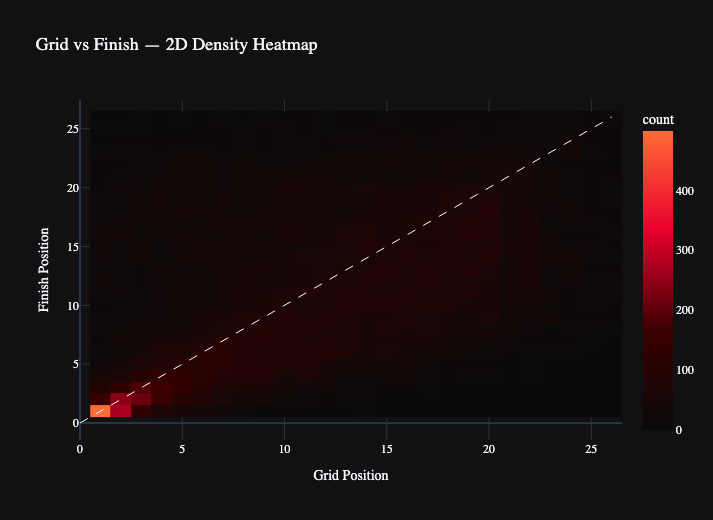

In [24]:
fig = px.density_heatmap(
    valid, x='Grid Position', y='Finish Position',
    nbinsx=26, nbinsy=26,
    color_continuous_scale=['#0a0a0a', '#3a0000', '#e8002d', '#ff6b35'],
    title='Grid vs Finish — 2D Density Heatmap',
    template='plotly_dark'
)

# Add diagonal reference
fig.add_trace(go.Scatter(
    x=list(range(0, 27)), y=list(range(0, 27)),
    mode='lines', line=dict(dash='dash', color='white', width=1),
    showlegend=False
))

fig.update_layout(
    font=dict(family='DM Sans'), title_font_size=18, height=520, width=560,
    xaxis_title='Grid Position', yaxis_title='Finish Position',
)
fig.show()

## 10. Pole-to-Win Conversion Rates

These stats appear as the key stat cards in the D3 application: what percentage of pole sitters (P1 on the grid) convert that into a win, broken down by circuit type.

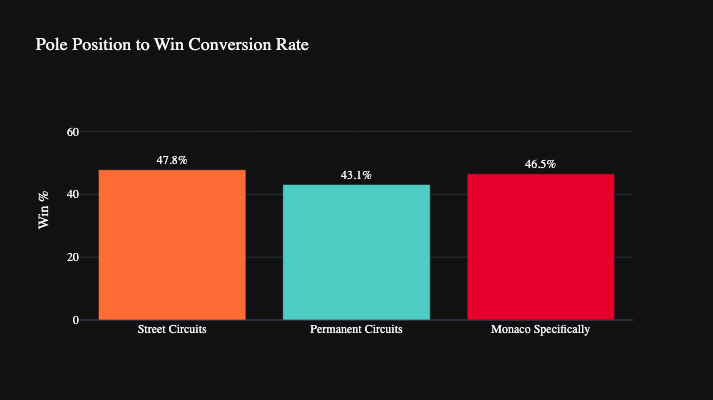


Detailed stats:


,Category,Pole-to-Win %,Total Poles
0,Street Circuits,47.8,136
1,Permanent Circuits,43.1,1006
2,Monaco Specifically,46.5,71


In [25]:
pole_sitters = valid[valid['Grid Position'] == 1]

street_pole = pole_sitters[pole_sitters['Circuit Type'] == 'Street Circuit']
perm_pole = pole_sitters[pole_sitters['Circuit Type'] == 'Permanent Circuit']
monaco_pole = pole_sitters[pole_sitters['Race Name'].str.contains('Monaco', na=False)]

street_win = (street_pole['Finish Position'] == 1).sum() / len(street_pole) * 100
perm_win = (perm_pole['Finish Position'] == 1).sum() / len(perm_pole) * 100
monaco_win = (monaco_pole['Finish Position'] == 1).sum() / len(monaco_pole) * 100

stats_data = pd.DataFrame({
    'Category': ['Street Circuits', 'Permanent Circuits', 'Monaco Specifically'],
    'Pole-to-Win %': [round(street_win, 1), round(perm_win, 1), round(monaco_win, 1)],
    'Total Poles': [len(street_pole), len(perm_pole), len(monaco_pole)]
})

fig = go.Figure(go.Bar(
    x=stats_data['Category'],
    y=stats_data['Pole-to-Win %'],
    marker_color=[STREET_COLOR, PERMANENT_COLOR, '#e8002d'],
    text=stats_data['Pole-to-Win %'].astype(str) + '%',
    textposition='outside'
))
fig.update_layout(
    title='Pole Position to Win Conversion Rate',
    yaxis_title='Win %', yaxis=dict(range=[0, 70]),
    template='plotly_dark', height=400,
    font=dict(family='DM Sans'), title_font_size=18,
)
fig.show()

print("\nDetailed stats:")
stats_data

## 11. Monaco 2024 Spotlight

The most extreme example of grid predictability in recent history — at Monaco 2024, the top 10 qualifiers finished in the exact same order. Zero overtakes in the top 10. This is highlighted in the D3 visualization with red circles on the diagonal.

Monaco 2024 entries: 16
Entries where Grid == Finish: 12



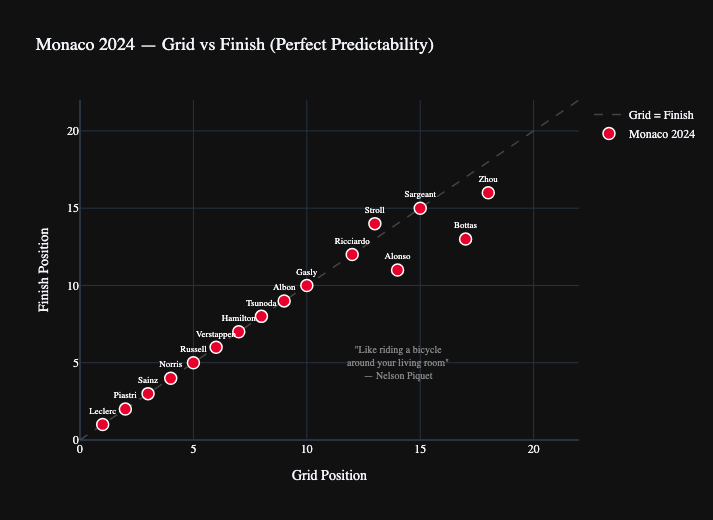

,Driver,Grid Position,Finish Position,Position Change
24494,Charles Leclerc,1.0,1.0,0.0
24495,Oscar Piastri,2.0,2.0,0.0
24496,Carlos Sainz,3.0,3.0,0.0
24497,Lando Norris,4.0,4.0,0.0
24498,George Russell,5.0,5.0,0.0
24499,Max Verstappen,6.0,6.0,0.0
24500,Lewis Hamilton,7.0,7.0,0.0
24501,Yuki Tsunoda,8.0,8.0,0.0
24502,Alexander Albon,9.0,9.0,0.0
24503,Pierre Gasly,10.0,10.0,0.0


In [26]:
monaco24 = valid[(valid['Year'] == 2024) & (valid['Race Name'].str.contains('Monaco', na=False))]
print(f"Monaco 2024 entries: {len(monaco24)}")
print(f"Entries where Grid == Finish: {(monaco24['Grid Position'] == monaco24['Finish Position']).sum()}")
print()

fig = go.Figure()

# Diagonal
fig.add_trace(go.Scatter(
    x=[0, 22], y=[0, 22], mode='lines',
    line=dict(dash='dash', color='#444444', width=1.5),
    name='Grid = Finish'
))

# Monaco 2024 dots
fig.add_trace(go.Scatter(
    x=monaco24['Grid Position'], y=monaco24['Finish Position'],
    mode='markers+text',
    marker=dict(size=12, color='#e8002d', symbol='circle',
                line=dict(color='white', width=1.5)),
    text=monaco24['Driver'].apply(lambda x: x.split()[-1]),
    textposition='top center',
    textfont=dict(size=9, color='white'),
    name='Monaco 2024'
))

fig.update_layout(
    title='Monaco 2024 — Grid vs Finish (Perfect Predictability)',
    xaxis_title='Grid Position', yaxis_title='Finish Position',
    xaxis=dict(range=[0, 22]), yaxis=dict(range=[0, 22]),
    template='plotly_dark', height=520, width=560,
    font=dict(family='DM Sans'), title_font_size=18,
    annotations=[dict(
        x=14, y=5, text='"Like riding a bicycle<br>around your living room"<br>— Nelson Piquet',
        showarrow=False, font=dict(size=10, color='#888888', family='DM Sans'),
    )]
)
fig.show()

monaco24[['Driver', 'Grid Position', 'Finish Position', 'Position Change']].sort_values('Grid Position')

## 12. Violin Plot — Position Changes by Circuit Type

Comparing the spread of position changes between street and permanent circuits. Street circuits should show a tighter distribution (less overtaking opportunity).

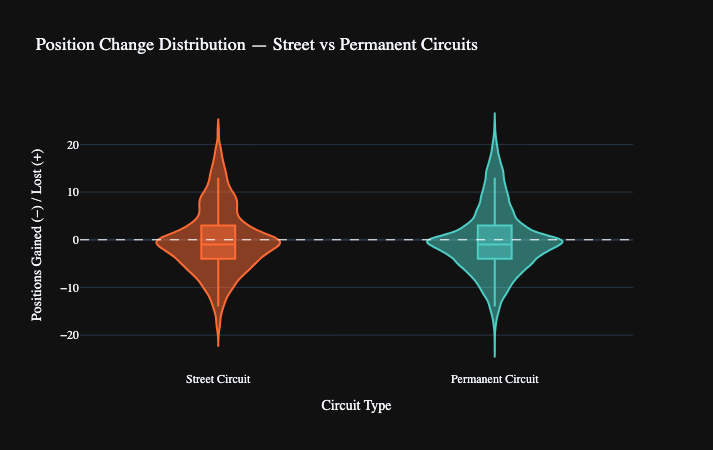

In [27]:
fig = px.violin(
    valid, x='Circuit Type', y='Position Change',
    color='Circuit Type',
    color_discrete_map={'Street Circuit': STREET_COLOR, 'Permanent Circuit': PERMANENT_COLOR},
    box=True, points=False,
    title='Position Change Distribution — Street vs Permanent Circuits',
    template='plotly_dark'
)
fig.add_hline(y=0, line_dash='dash', line_color='white', line_width=1)
fig.update_layout(
    font=dict(family='DM Sans'), title_font_size=18, height=450,
    showlegend=False,
    yaxis_title='Positions Gained (−) / Lost (+)'
)
fig.show()

## 13. Correlation by Track — Most vs Least Predictable Circuits

Calculating the Pearson correlation (R) between grid and finish position for each individual track. Tracks with higher R are more predictable (qualifying determines the race).

/var/folders/9r/jpz6t9fx7jv6tyyxhcmg5k200000gn/T/ipykernel_57355/1117532887.py:2: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



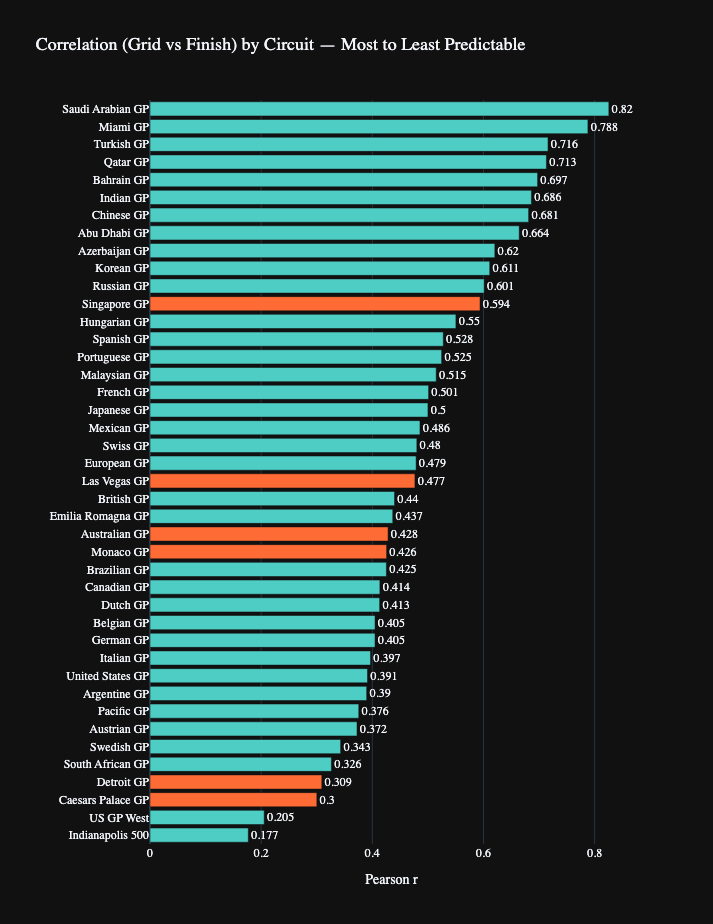

In [28]:
# Min 50 entries per track
track_corr = valid.groupby('Race Name').apply(
    lambda g: pd.Series({
        'r': g['Grid Position'].corr(g['Finish Position']),
        'entries': len(g),
        'circuit_type': g['Circuit Type'].mode().iloc[0] if len(g) > 0 else 'Unknown'
    })
).reset_index()
track_corr = track_corr[track_corr['entries'] >= 50].sort_values('r', ascending=True)

colors = [STREET_COLOR if ct == 'Street Circuit' else PERMANENT_COLOR 
          for ct in track_corr['circuit_type']]

fig = go.Figure(go.Bar(
    y=track_corr['Race Name'],
    x=track_corr['r'],
    orientation='h',
    marker_color=colors,
    text=track_corr['r'].round(3), textposition='outside'
))
fig.update_layout(
    title='Correlation (Grid vs Finish) by Circuit — Most to Least Predictable',
    xaxis_title='Pearson r', yaxis_title='',
    template='plotly_dark', height=max(400, len(track_corr) * 22),
    font=dict(family='DM Sans'), title_font_size=18,
    margin=dict(l=150)
)
fig.show()

---
## Key Findings

1. **Grid position is a strong predictor of finish position** — the overall correlation is significant across all circuit types.
2. **Street circuits are more predictable** than permanent circuits — narrower streets make overtaking nearly impossible.
3. **Monaco is the extreme** — the pole-to-win conversion rate at Monaco exceeds other street circuits, and Monaco 2024 demonstrated this perfectly with zero top-10 position changes.
4. **The 2D density heatmap** reveals that the most common outcome is finishing within 2-3 positions of your grid slot, with the heaviest density along the diagonal.
5. **Per-track correlation** shows meaningful variance — some circuits (likely Monaco, Singapore) consistently show higher predictability than others.

These insights led to the D3 design decisions: circuit type color coding (orange/teal), regression line overlays with r-values, the Monaco 2024 highlight, and the stat cards showing pole-to-win conversion rates.